In [24]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score
)

NOTEBOOK_DIR = Path('.').resolve()
DATA_DIR     = NOTEBOOK_DIR

FEATURES    = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']
CLASS_NAMES = ['Normal', 'Cooking', 'Fire']
RS          = 42


In [25]:
df = pd.read_excel(DATA_DIR / 'merged_dataset.xlsx')

print('Shape:', df.shape)
print('Class distribution:')
for name in CLASS_NAMES:
    n = (df['label'] == name).sum()
    print(f'  {name:8s}: {n:6d} ({n/len(df)*100:.1f}%)')


Shape: (60212, 6)
Class distribution:
  Normal  :  14671 (24.4%)
  Cooking :   4718 (7.8%)
  Fire    :  40823 (67.8%)


In [26]:
X = df[FEATURES].values
y = df['class_id'].values

# 70 / 15 / 15 stratified split
# test set is locked — not seen until final evaluation
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RS, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15/0.85, random_state=RS, stratify=y_tv)

print(f'Train : {len(y_train):,}')
print(f'Val   : {len(y_val):,}')
print(f'Test  : {len(y_test):,}')
print()
print('Train class distribution:')
for cid, name in enumerate(CLASS_NAMES):
    n = (y_train == cid).sum()
    if n: print(f'  {name}: {n:,} ({n/len(y_train)*100:.1f}%)')
print()
print('Test class distribution (stratified = proportional):')
for cid, name in enumerate(CLASS_NAMES):
    n = (y_test == cid).sum()
    if n: print(f'  {name}: {n:,} ({n/len(y_test)*100:.1f}%)')


Train : 42,148
Val   : 9,032
Test  : 9,032

Train class distribution:
  Normal: 10,270 (24.4%)
  Cooking: 3,302 (7.8%)
  Fire: 28,576 (67.8%)

Test class distribution (stratified = proportional):
  Normal: 2,201 (24.4%)
  Cooking: 708 (7.8%)
  Fire: 6,123 (67.8%)


In [27]:
# scaler fitted on train only — transform val and test with same scaler
# fitting on all data would leak test distribution into training
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaler fitted on train only.')
print('Means:', dict(zip(FEATURES, scaler.mean_.round(2))))
print('Stds :', dict(zip(FEATURES, scaler.scale_.round(2))))


Scaler fitted on train only.
Means: {'temperature': np.float64(17.69), 'humidity': np.float64(50.09), 'tvoc_ppb': np.float64(654.62), 'eco2_ppm': np.float64(464.63)}
Stds : {'temperature': np.float64(11.53), 'humidity': np.float64(5.07), 'tvoc_ppb': np.float64(598.43), 'eco2_ppm': np.float64(142.34)}


In [28]:
from sklearn.ensemble import GradientBoostingClassifier

# Baseline Gradient Boosting model
gb_base = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RS,
)
gb_base.fit(X_train_sc, y_train)
print('Baseline Gradient Boosting trained.')


Baseline Gradient Boosting trained.


In [29]:
# Validation evaluation for baseline GB
y_val_pred = gb_base.predict(X_val_sc)

print('=== GB Baseline — validation set ===')
print(classification_report(y_val, y_val_pred,
      target_names=CLASS_NAMES, labels=[0,1,2], zero_division=0))

cm_val = confusion_matrix(y_val, y_val_pred, labels=[0,1,2])
print(f'Fire recall (priority 1)           : {cm_val[2,2]/cm_val[2].sum():.4f}')
print(f'Cooking → Fire errors (priority 2) : {cm_val[1,2]}')


=== GB Baseline — validation set ===
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      2200
     Cooking       1.00      0.97      0.98       708
        Fire       0.99      1.00      0.99      6124

    accuracy                           0.99      9032
   macro avg       0.99      0.98      0.99      9032
weighted avg       0.99      0.99      0.99      9032

Fire recall (priority 1)           : 0.9976
Cooking → Fire errors (priority 2) : 5


In [30]:
# GridSearchCV for Gradient Boosting on the same stratified subsample
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.05],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RS),
    param_grid_gb, cv=skf, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search.fit(X_gs, y_gs)

print('GB Best params    :', grid_search.best_params_)
print('GB Best CV F1-macro:', round(grid_search.best_score_, 4))


Fitting 3 folds for each of 32 candidates, totalling 96 fits
GB Best params    : {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}
GB Best CV F1-macro: 0.9859


In [31]:
# Retrain best GB configuration on full training set
gb_best = GradientBoostingClassifier(
    **grid_search.best_params_,
    random_state=RS,
)
gb_best.fit(X_train_sc, y_train)

y_val_pred_tuned = gb_best.predict(X_val_sc)

print('=== Tuned GB — validation set ===')
print(classification_report(y_val, y_val_pred_tuned,
      target_names=CLASS_NAMES, labels=[0,1,2], zero_division=0))

cm_val_t = confusion_matrix(y_val, y_val_pred_tuned, labels=[0,1,2])
print(f'Fire recall (priority 1)           : {cm_val_t[2,2]/cm_val_t[2].sum():.4f}')
print(f'Cooking → Fire errors (priority 2) : {cm_val_t[1,2]}')


=== Tuned GB — validation set ===
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2200
     Cooking       1.00      0.99      0.99       708
        Fire       1.00      1.00      1.00      6124

    accuracy                           1.00      9032
   macro avg       1.00      0.99      0.99      9032
weighted avg       1.00      1.00      1.00      9032

Fire recall (priority 1)           : 0.9989
Cooking → Fire errors (priority 2) : 1


=== GB FINAL — test set (unseen data) ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      2201
     Cooking       1.00      0.99      0.99       708
        Fire       0.99      1.00      1.00      6123

    accuracy                           1.00      9032
   macro avg       1.00      0.99      0.99      9032
weighted avg       1.00      1.00      1.00      9032

Fire recall (priority 1)           : 0.9992
Cooking → Fire errors (priority 2) : 4
Macro F1                           : 0.9938


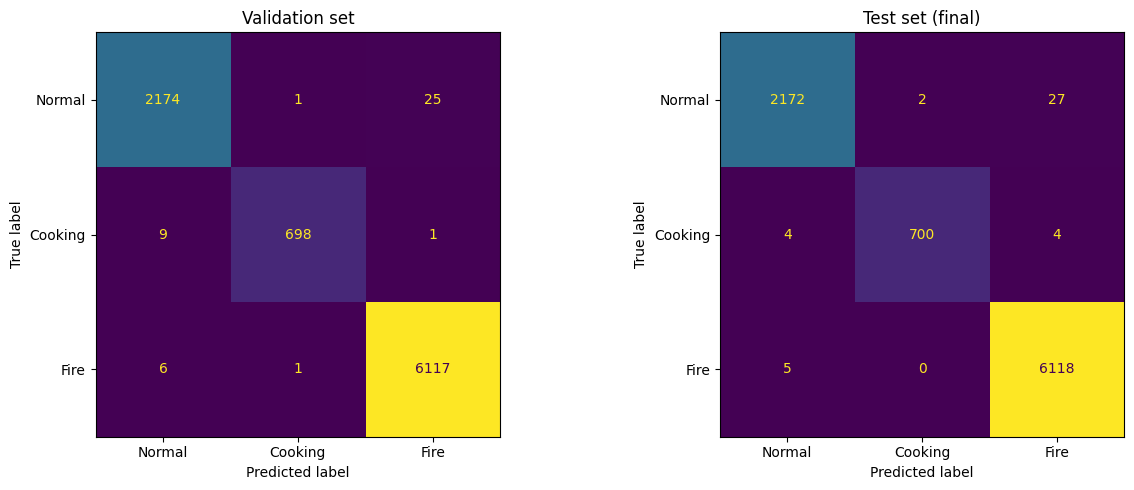

In [32]:
# Final evaluation — test set for GB
y_test_pred = gb_best.predict(X_test_sc)

print('=== GB FINAL — test set (unseen data) ===')
print(classification_report(y_test, y_test_pred,
      target_names=CLASS_NAMES, labels=[0,1,2], zero_division=0))

cm_test = confusion_matrix(y_test, y_test_pred, labels=[0,1,2])
print(f'Fire recall (priority 1)           : {cm_test[2,2]/cm_test[2].sum():.4f}')
print(f'Cooking → Fire errors (priority 2) : {cm_test[1,2]}')
print(f'Macro F1                           : {f1_score(y_test, y_test_pred, average="macro", zero_division=0):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (y_true, y_pred, title) in zip(axes, [
        (y_val,  y_val_pred_tuned, 'Validation set'),
        (y_test, y_test_pred,      'Test set (final)'),
]):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [ ]:
# per-class recall shows how fairly the model performs across all 3 classes
# macro recall gives equal weight to each class regardless of size
recalls = recall_score(y_test, y_test_pred, labels=[0,1,2], average=None, zero_division=0)

plt.figure(figsize=(6, 4))
bars = plt.bar(CLASS_NAMES, recalls, color=['steelblue','tomato','gold'], alpha=0.85)
plt.ylim(0, 1.15)
plt.ylabel('Recall')
plt.title('Per-class recall — test set')
for bar, val in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


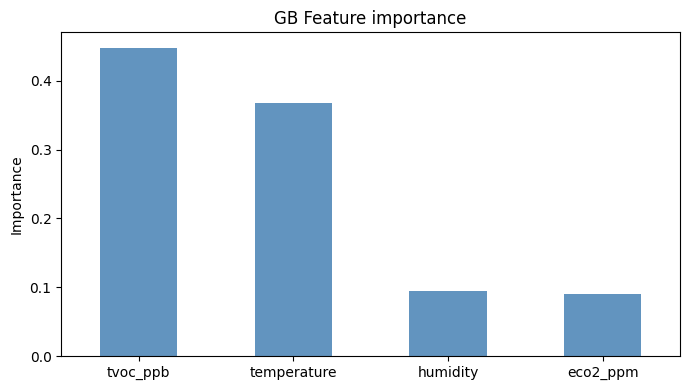

tvoc_ppb       0.4478
temperature    0.3670
humidity       0.0948
eco2_ppm       0.0904
Train F1-macro : 0.9999
Val   F1-macro : 0.9931
Test  F1-macro : 0.9938
Train-test gap : 0.0062
no overfitting
Saved model_gb.joblib


In [33]:
# Feature importance, per-class recall, and save GB model
fi = pd.Series(gb_best.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7,4))
fi.plot.bar(color='steelblue', alpha=0.85)
plt.title('GB Feature importance')
plt.ylabel('Importance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(fi.round(4).to_string())

train_f1 = f1_score(y_train, gb_best.predict(X_train_sc), average='macro', zero_division=0)
val_f1   = f1_score(y_val,   y_val_pred_tuned,         average='macro', zero_division=0)
test_f1  = f1_score(y_test,  y_test_pred,              average='macro', zero_division=0)
gap      = train_f1 - test_f1

print(f'Train F1-macro : {train_f1:.4f}')
print(f'Val   F1-macro : {val_f1:.4f}')
print(f'Test  F1-macro : {test_f1:.4f}')
print(f'Train-test gap : {gap:.4f}')
print('no overfitting' if gap < 0.02 else 'mild overfitting' if gap < 0.05 else 'overfitting detected')

joblib.dump(gb_best, NOTEBOOK_DIR / 'model_gb.joblib')
print('Saved model_gb.joblib')
